<a href="https://colab.research.google.com/github/ian-menachery/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%201/Econ_3916_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# Manual Data Construction
student_basket = [
    {'Item': 'Tuition', 'Price_2016': 45000, 'Price_2024': 58000},
    {'Item': 'Rent (1 Bed)', 'Price_2016': 1200, 'Price_2024': 1800},
    {'Item': 'Chipotle Burrito', 'Price_2016': 7.50, 'Price_2024': 11.50},
    {'Item': 'Spotify', 'Price_2016': 5, 'Price_2024': 7}
]

In [14]:
# Define the "Machine" (Function)
def calculate_inflation(base, current):
    return ((current - base) / base) * 100

# Run the Loop
for item in student_basket:
    rate = calculate_inflation(item['Price_2016'], item['Price_2024'])
    print(f"{item['Item']}: {rate:.2f}% Inflation")

Tuition: 28.89% Inflation
Rent (1 Bed): 50.00% Inflation
Chipotle Burrito: 53.33% Inflation
Spotify: 40.00% Inflation


In [15]:
from fredapi import Fred
fred = Fred(api_key='b2c03fac971d285ab168f3c7c6c0a13f')

# Fetch Series
official_cpi = fred.get_series('CPIAUCSL')
tuition = fred.get_series('CUSR0000SEEB')
rent = fred.get_series('CUSR0000SEHA')
entertainment_proxy = fred.get_series('CUSR0000SERA02')
dining_proxy = fred.get_series('CUSR0000SEFV')

In [16]:

import pandas as pd

df = pd.DataFrame({
    'Official_CPI': official_cpi,
    'Tuition_Fees': tuition,
    'Rent': rent,
    'Streaming_Proxy': entertainment_proxy,
    'Dining_Proxy': dining_proxy
}).dropna()

start_date = '2016-01-01'
df_filtered = df.loc[start_date:].dropna()

value_at_start_date = df_filtered.iloc[0]
df_indexed = (df_filtered / value_at_start_date) * 100

print(df_indexed.head())

            Official_CPI  Tuition_Fees        Rent  Streaming_Proxy  \
2016-01-01    100.000000    100.000000  100.000000       100.000000   
2016-02-01     99.867032    100.241572  100.314364       100.723912   
2016-03-01    100.180095    100.470288  100.607131       101.450163   
2016-04-01    100.563850    100.692146  100.924580       101.878663   
2016-05-01    100.801592    100.929861  101.258485       102.214306   

            Dining_Proxy  
2016-01-01    100.000000  
2016-02-01    100.138869  
2016-03-01    100.355827  
2016-04-01    100.599712  
2016-05-01    100.813978  


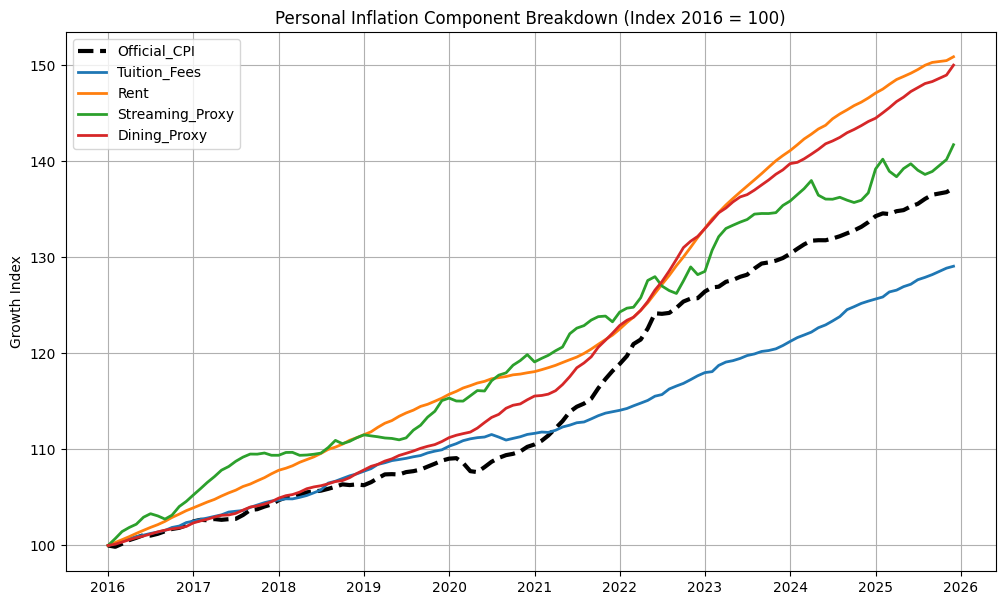

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

for col in df_indexed.columns:
    is_cpi = col == 'Official_CPI'
    plt.plot(df_indexed.index, df_indexed[col],
             label=col,
             color='black' if is_cpi else None,
             linewidth=3 if is_cpi else 2,
             linestyle='--' if is_cpi else '-')

plt.title('Personal Inflation Component Breakdown (Index 2016 = 100)')
plt.ylabel('Growth Index')
plt.legend()
plt.grid(True)
plt.show()

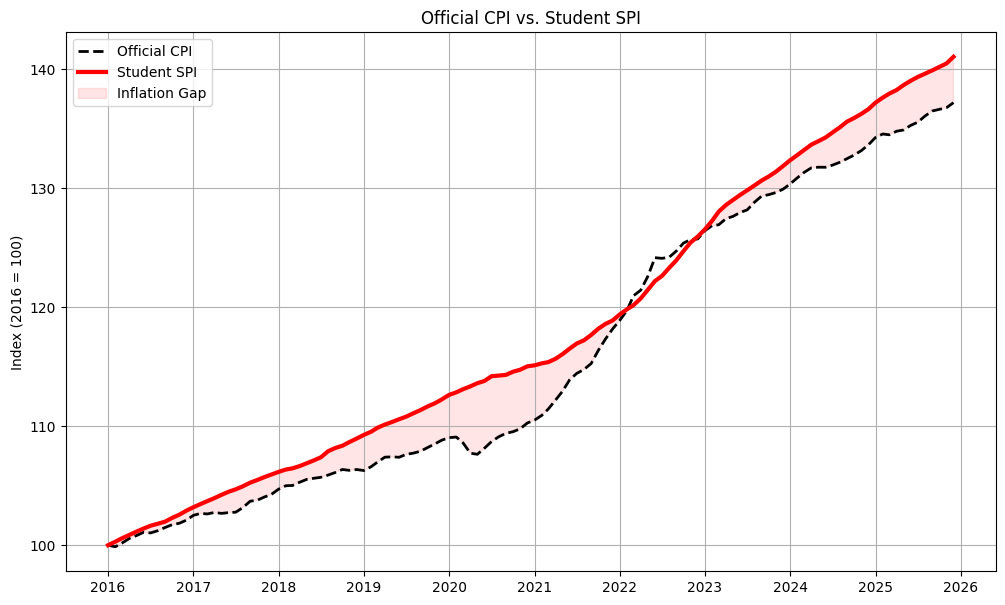

In [20]:
import matplotlib.pyplot as plt

weights = {
    'Tuition': 0.40,
    'Rent': 0.30,
    'Dining_Proxy': 0.20,
    'Streaming_Proxy': 0.10
}

df_indexed['Student_SPI'] = (
    df_indexed['Tuition_Fees'] * weights['Tuition'] +
    df_indexed['Rent'] * weights['Rent'] +
    df_indexed['Dining_Proxy'] * weights['Dining_Proxy'] +
    df_indexed['Streaming_Proxy'] * weights['Streaming_Proxy']
)

plt.figure(figsize=(12, 7))

plt.plot(df_indexed.index, df_indexed['Official_CPI'],
         label='Official CPI', color='black', linewidth=2, linestyle='--')

plt.plot(df_indexed.index, df_indexed['Student_SPI'],
         label='Student SPI', color='red', linewidth=3)

plt.fill_between(df_indexed.index,
                 df_indexed['Official_CPI'],
                 df_indexed['Student_SPI'],
                 where=(df_indexed['Student_SPI'] > df_indexed['Official_CPI']),
                 color='red', alpha=0.1, label='Inflation Gap')

plt.title('Official CPI vs. Student SPI')
plt.ylabel('Index (2016 = 100)')
plt.legend()
plt.grid(True)
plt.show()

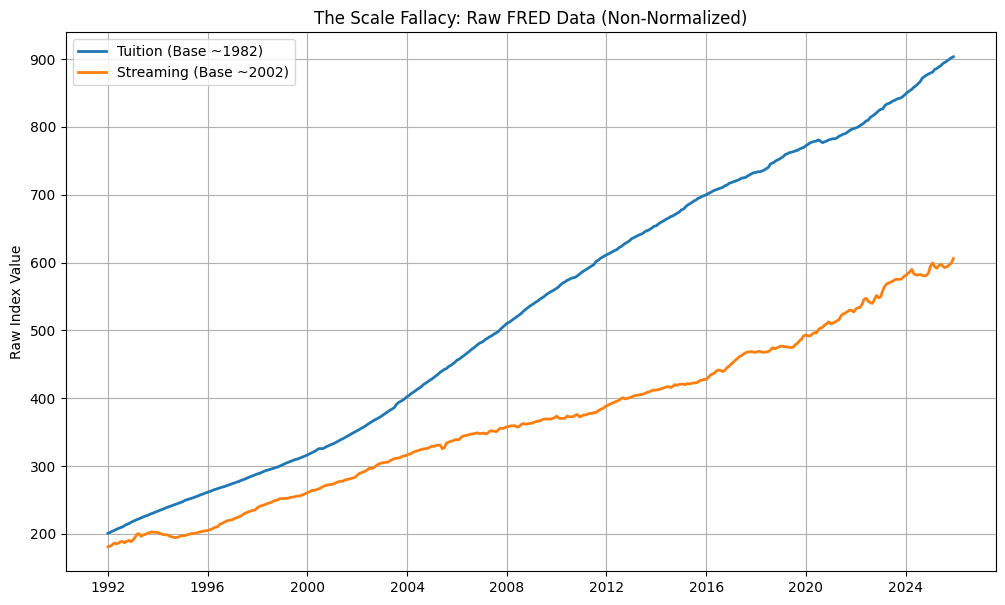

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Plotting Raw Data (Non-Normalized)
plt.plot(df.index, df['Tuition_Fees'], label='Tuition (Base ~1982)', linewidth=2)
plt.plot(df.index, df['Streaming_Proxy'], label='Streaming (Base ~2002)', linewidth=2)

plt.title('The Scale Fallacy: Raw FRED Data (Non-Normalized)')
plt.ylabel('Raw Index Value')
plt.legend()
plt.grid(True)
plt.show()

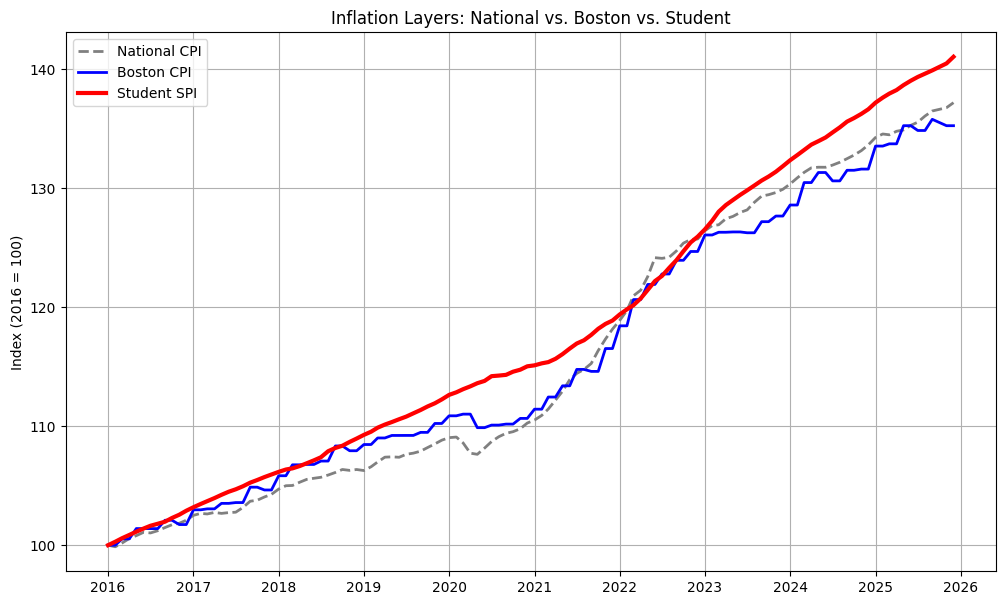

In [26]:
import matplotlib.pyplot as plt

boston_raw = fred.get_series('CUURA103SA0')

df_indexed['Boston_CPI_Raw'] = boston_raw.reindex(df_indexed.index)
df_indexed['Boston_CPI_Raw'] = df_indexed['Boston_CPI_Raw'].ffill()

boston_start_val = df_indexed['Boston_CPI_Raw'].iloc[0]
df_indexed['Boston_CPI'] = (df_indexed['Boston_CPI_Raw'] / boston_start_val) * 100

plt.figure(figsize=(12, 7))

plt.plot(df_indexed.index, df_indexed['Official_CPI'],
         label='National CPI', color='grey', linewidth=2, linestyle='--')

plt.plot(df_indexed.index, df_indexed['Boston_CPI'],
         label='Boston CPI', color='blue', linewidth=2)

plt.plot(df_indexed.index, df_indexed['Student_SPI'],
         label='Student SPI', color='red', linewidth=3)

plt.title('Inflation Layers: National vs. Boston vs. Student')
plt.ylabel('Index (2016 = 100)')
plt.legend()
plt.grid(True)
plt.show()